In [1]:
from pylab import *
from lib.circuitSolver import *
from lib.generate_graph import *
from lib.tableau import *
from optimization_script import *
from tqdm.notebook import tqdm
import networkx as nx
import random
import math
import time
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

In [2]:
def sample_random_graphs(n,p, num_shots = 1024, create_circiut=True):
    n_e_results = []
    num_cnots = []
    for i in tqdm(range(num_shots)):
        connected = False
        while connected is False:
            try:
                graph = nx.erdos_renyi_graph(n,p)
                connected = (len(max(nx.connected_components(graph), key=len)) ==graph.number_of_nodes())
            except:
                pass
        
        start_time = time.time()
        adj = nx.adjacency_matrix(graph,nodelist=list(range(graph.number_of_nodes()))).toarray()
        tableau = stabTableau(GraphstateGenerator.get_tableau_from_adj(adj))
        print("Tableau creation time/h0: ",time.time()-start_time)
        n_e_results.append(tableau.n_e)
        if create_circiut:
            _, cnot_count = algorithm(tableau,start_emitter=[0,0,0],optimize=False,return_num_cnots=True)
            num_cnots.append(cnot_count)
    return n_e_results,num_cnots

def optimized_sample_random_graphs(n,p, num_shots = 1024, create_circuit=True,edge_reduction=True,minLA=True,opt_CNOT=True):
    n_e_results = []
    num_cnots = []
    for i in tqdm(range(num_shots)):
        connected = False
        while connected is False:
            try:
                graph = nx.erdos_renyi_graph(n,p)
                connected = (len(max(nx.connected_components(graph), key=len)) ==graph.number_of_nodes())
            except:
                pass

        if create_circuit:
            opt_graph, circuit, stats = run_optimization(graph.copy(),edge_reduction=edge_reduction,minLA=minLA,num_LA=5,opt_CNOT=opt_CNOT)
            num_cnots.append(stats[1])
            n_e_results.append(stats[0])
    return n_e_results,num_cnots


In [3]:
n_p_tests = 2**np.arange(1,5,1)
n_p = 20
p_tests = np.arange(0.075,1,0.075)
p = 0.05

In [4]:
mean_em = []
mean_cnot = []
for p in p_tests:
    n_e_results,num_cnots = sample_random_graphs(n_p,p,num_shots=100,create_circiut=True)
    mean_em.append([mean(n_e_results),std(n_e_results)])
    mean_cnot.append([mean(num_cnots),std(num_cnots)])

  0%|          | 0/100 [00:00<?, ?it/s]

Tableau creation time/h0:  0.005361080169677734
Tableau creation time/h0:  0.004000425338745117
Tableau creation time/h0:  0.0019989013671875
Tableau creation time/h0:  0.003083944320678711
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.002252340316772461
Tableau creation time/h0:  0.006756782531738281
Tableau creation time/h0:  0.0020051002502441406
Tableau creation time/h0:  0.0025200843811035156
Tableau creation time/h0:  0.0028994083404541016
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0019001960754394531
Tableau creation time/h0:  0.0021543502807617188
Tableau creation time/h0:  0.0030050277709960938
Tableau creation time/h0:  0.002528667449951172
Tableau creation time/h0:  0.002171754837036133
Tableau creation time/h0:  0.008317947387695312
Tableau creation time/h0:  0.003948211669921875
Tableau creation time/h0:  0.002268552780151367
Tableau creation time/h0:  0.002998828887939453
Tableau creation time/h0:  0.0031652450561523438
Tableau creation time

  0%|          | 0/100 [00:00<?, ?it/s]

Tableau creation time/h0:  0.006160736083984375
Tableau creation time/h0:  0.010272979736328125
Tableau creation time/h0:  0.002966642379760742
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0019736289978027344
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0036110877990722656
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0029153823852539062
Tableau creation time/h0:  0.002314329147338867
Tableau creation time/h0:  0.008479833602905273
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0011472702026367188
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.004255771636962891
Tableau creation time/h0:  0.0016248226165771484
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0018110275268554688
Tableau creation time/h0:  0.0009915828704833984
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.00189208984375
Tableau creatio

  0%|          | 0/100 [00:00<?, ?it/s]

...

Tableau creation time/h0:  0.00457310676574707
Tableau creation time/h0:  0.011886835098266602
Tableau creation time/h0:  0.0020339488983154297
Tableau creation time/h0:  0.0011086463928222656
Tableau creation time/h0:  0.001997709274291992
Tableau creation time/h0:  0.002949237823486328
Tableau creation time/h0:  0.0024483203887939453
Tableau creation time/h0:  0.0028281211853027344
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.005078792572021484
Tableau creation time/h0:  0.003460407257080078
Tableau creation time/h0:  0.002962350845336914
Tableau creation time/h0:  0.008359909057617188
Tableau creation time/h0:  0.0031273365020751953
Tableau creation time/h0:  0.0010995864868164062
Tableau creation time/h0:  0.011540889739990234
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.003038167953491211
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.002050638198852539
Tableau creation time/h0:  0.0013344287872314453
Tablea

  0%|          | 0/100 [00:00<?, ?it/s]

Tableau creation time/h0:  0.012936830520629883
Tableau creation time/h0:  0.003367900848388672
Tableau creation time/h0:  0.003037691116333008
Tableau creation time/h0:  0.0028829574584960938
Tableau creation time/h0:  0.007523775100708008
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.003000974655151367
Tableau creation time/h0:  0.0010585784912109375
Tableau creation time/h0:  0.0019989013671875
Tableau creation time/h0:  0.00459742546081543
Tableau creation time/h0:  0.008800029754638672
Tableau creation time/h0:  0.003927946090698242
Tableau creation time/h0:  0.0014650821685791016
Tableau creation time/h0:  0.011520147323608398
Tableau creation time/h0:  0.0018775463104248047
Tableau creation time/h0:  0.003975629806518555
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0010781288146972656
Tableau creation time/h0:  0.0019989013671875
Tableau creation time/h0:  0.007359504699707031
Tableau crea

  0%|          | 0/100 [00:00<?, ?it/s]

Tableau creation time/h0:  0.005637645721435547
Tableau creation time/h0:  0.0020198822021484375
Tableau creation time/h0:  0.0050008296966552734
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.009007930755615234
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.00407862663269043
Tableau creation time/h0:  0.0042133331298828125
Tableau creation time/h0:  0.0019974708557128906
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.002218484878540039
Tableau creation time/h0:  0.0021009445190429688
Tableau creation time/h0:  0.00843501091003418
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0020380020141601562
Tableau creation time/h0:  0.011829376220703125
Tableau creation time/h0:  0.0010046958923339844
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.0020020008087158203
Tableau creation time/h0:  0.0
Tableau creation time/h0:  0.001986980438232422
Tableau creation time/h0:  0.009288787841796875
Tableau c

In [5]:
opt_mean_em = []
opt_mean_cnot = []
double_opt_mean_cnot = []
for p in p_tests:
    #n_e_results,num_cnots = optimized_sample_random_graphs(n_p,0.95,num_shots=100,create_circuit=False,reduce_n_e=False)
    #opt_mean_cnot.append([mean(num_cnots),std(num_cnots)]) 
    n_e_results,num_cnots = optimized_sample_random_graphs(n_p,p,num_shots=100,create_circuit=True)
    opt_mean_em.append([mean(n_e_results),std(n_e_results)])
    double_opt_mean_cnot.append([mean(num_cnots),std(num_cnots)]) 

  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\NilsOttink\OneDrive - Quandela\Documents\photonic-graphstate-generator\lib\generate_graph.py:142: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


3 inf
3 3
4 3
4 3
3 3
Circuit generates correct graph
5 inf
4 5
4 4
4 4
4 4
Circuit generates correct graph
5 inf
4 5
4 4
4 4
4 4
Circuit generates correct graph
4 inf
4 4
4 4
4 4
4 4
Circuit generates correct graph
4 inf
3 4
4 3
3 3
4 3
Circuit generates correct graph
4 inf
4 4
3 4
3 3
5 3
Circuit generates correct graph
3 inf
2 3
2 2
2 2
2 2
Circuit generates correct graph
4 inf
4 4
5 4
5 4
5 4
Circuit generates correct graph
3 inf
3 3
3 3
3 3
3 3
Circuit generates correct graph
3 inf
4 3
4 3
3 3
3 3
Circuit generates correct graph
2 inf
2 2
3 2
3 2
2 2
Circuit generates correct graph
4 inf
4 4
3 4
3 3
4 3
Circuit generates correct graph
4 inf
3 4
3 3
2 3
4 2
Circuit generates correct graph
3 inf
3 3
3 3
5 3
3 3
Circuit generates correct graph
4 inf
4 4
3 4
3 3
3 3
Circuit generates correct graph
5 inf
5 5
5 5
5 5
5 5
Circuit generates correct graph
2 inf
2 2
2 2
3 2
3 2
Circuit generates correct graph
3 inf
4 3
3 3
4 3
4 3
Circuit generates correct graph
4 inf
4 4
4 4
4 4
3 4
Circui

  0%|          | 0/100 [00:00<?, ?it/s]

6 inf
6 6
6 6
5 6
5 5
Circuit generates correct graph
5 inf
6 5
5 5
5 5
5 5
Circuit generates correct graph
6 inf
5 6
5 5
5 5
5 5
Circuit generates correct graph
6 inf
6 6
6 6
6 6
6 6
Circuit generates correct graph
4 inf
4 4
5 4
4 4
4 4
Circuit generates correct graph
5 inf
5 5
6 5
5 5
5 5
Circuit generates correct graph
7 inf
7 7
7 7
7 7
7 7
Circuit generates correct graph
5 inf
5 5
5 5
6 5
6 5
Circuit generates correct graph
6 inf
5 6
5 5
6 5
5 5
Circuit generates correct graph
6 inf
6 6
6 6
7 6
6 6
Circuit generates correct graph
6 inf
5 6
5 5
5 5
6 5
Circuit generates correct graph
4 inf
4 4
4 4
4 4
3 4
Circuit generates correct graph
7 inf
7 7
5 7
5 5
5 5
Circuit generates correct graph
6 inf
6 6
5 6
5 5
5 5
Circuit generates correct graph
6 inf
7 6
5 6
6 5
6 5
Circuit generates correct graph
5 inf
5 5
5 5
5 5
5 5
Circuit generates correct graph
5 inf
5 5
5 5
5 5
5 5
Circuit generates correct graph
5 inf
5 5
5 5
5 5
5 5
Circuit generates correct graph
5 inf
5 5
5 5
5 5
5 5
Circui

...

10 inf
9 10
9 9
9 9
8 9
Circuit generates correct graph
7 inf
9 7
9 7
9 7
8 7
Circuit generates correct graph
8 inf
9 8
9 8
9 8
10 8
Circuit generates correct graph
6 inf
6 6
6 6
5 6
6 5
Circuit generates correct graph
7 inf
8 7
8 7
8 7
9 7
Circuit generates correct graph
7 inf
7 7
7 7
7 7
6 7
Circuit generates correct graph
8 inf
7 8
7 7
7 7
7 7
Circuit generates correct graph
5 inf
5 5
5 5
5 5
5 5
Circuit generates correct graph
8 inf
9 8
8 8
8 8
8 8
Circuit generates correct graph
9 inf
8 9
9 8
8 8
7 8
Circuit generates correct graph
7 inf
7 7
7 7
7 7
7 7
Circuit generates correct graph
6 inf
6 6
7 6
6 6
6 6
Circuit generates correct graph
7 inf
6 7
8 6
6 6
6 6
Circuit generates correct graph
6 inf
5 6
5 5
5 5
5 5
Circuit generates correct graph
5 inf
5 5
6 5
5 5
5 5
Circuit generates correct graph
8 inf
7 8
7 7
8 7
7 7
Circuit generates correct graph
7 inf
7 7
8 7
7 7
7 7
Circuit generates correct graph
5 inf
5 5
5 5
5 5
5 5
Circuit generates correct graph
8 inf
8 8
7 8
7 7
7 7
Cir

  0%|          | 0/100 [00:00<?, ?it/s]

5 inf
5 5
5 5
5 5
4 5
Circuit generates correct graph
3 inf
4 3
4 3
4 3
4 3
Circuit generates correct graph
3 inf
3 3
3 3
3 3
4 3
Circuit generates correct graph
3 inf
3 3
3 3
3 3
3 3
Circuit generates correct graph
3 inf
3 3
3 3
3 3
3 3
Circuit generates correct graph
5 inf
5 5
5 5
5 5
5 5
Circuit generates correct graph
4 inf
4 4
3 4
4 3
4 3
Circuit generates correct graph
3 inf
4 3
4 3
4 3
4 3
Circuit generates correct graph
3 inf
3 3
4 3
3 3
5 3
Circuit generates correct graph
6 inf
4 6
4 4
4 4
4 4
Circuit generates correct graph
4 inf
4 4
4 4
4 4
4 4
Circuit generates correct graph
5 inf
4 5
4 4
4 4
5 4
Circuit generates correct graph
4 inf
5 4
5 4
4 4
4 4
Circuit generates correct graph
5 inf
4 5
5 4
4 4
4 4
Circuit generates correct graph
5 inf
4 5
3 4
3 3
4 3
Circuit generates correct graph
4 inf
4 4
4 4
4 4
4 4
Circuit generates correct graph
4 inf
3 4
4 3
3 3
3 3
Circuit generates correct graph
4 inf
4 4
4 4
4 4
4 4
Circuit generates correct graph
4 inf
4 4
4 4
3 4
4 3
Circui

  0%|          | 0/100 [00:00<?, ?it/s]

2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
1 2
1 1
1 1
2 1
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
3 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
1 2
1 1
2 1
1 1
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
2 inf
2 2
2 2
2 2
2 2
Circui

In [6]:
mean_em = np.array(mean_em).T
mean_cnot = np.array(mean_cnot).T
print(mean_em)
print(mean_cnot)

[[7.1        7.76       8.66       8.92       9.21       9.24
  9.33       9.27       9.28       9.05       8.52       6.91
  3.68      ]
 [0.91104336 0.78892332 0.80274529 0.61122827 0.55308227 0.51224994
  0.5487258  0.56311633 0.49152823 0.58949131 0.8885944  0.9283857
  1.02839681]]
[[21.16       38.59       57.98       74.1        82.11       85.41
  87.91       88.32       86.98       83.82       70.7        43.49
  12.31      ]
 [ 7.20516481 11.52744117 10.23716758  9.22117129  8.31131157  6.57281523
   7.45800912  7.63135637  7.41886784  8.33832117 12.60912368 12.43904739
   5.60481043]]


In [7]:
opt_mean_em = np.array(opt_mean_em).T
opt_mean_cnot = np.array(opt_mean_cnot).T
double_opt_mean_cnot = np.array(double_opt_mean_cnot).T
print(opt_mean_em)
print(opt_mean_cnot)
print(double_opt_mean_cnot)

[[3.1        4.76       6.43       7.9        8.52       8.66
  8.8        8.76       8.67       7.76       6.23       3.59
  1.85      ]
 [0.81853528 0.92865494 1.01247222 0.84261498 0.574108   0.53329167
  0.50990195 0.51224994 0.49101935 0.82607506 0.98848369 0.80118662
  0.4330127 ]]
[]
[[ 7.92       19.07       36.3        55.26       64.79       67.69
  68.72       69.34       66.67       54.93       37.34       15.71
   2.52      ]
 [ 4.18253512  6.37535097 10.84204778 10.91203006  8.31540137  7.66119442
   7.2222988   6.70554994  8.57794264  9.24148798  9.49022655  4.69104466
   1.96712989]]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


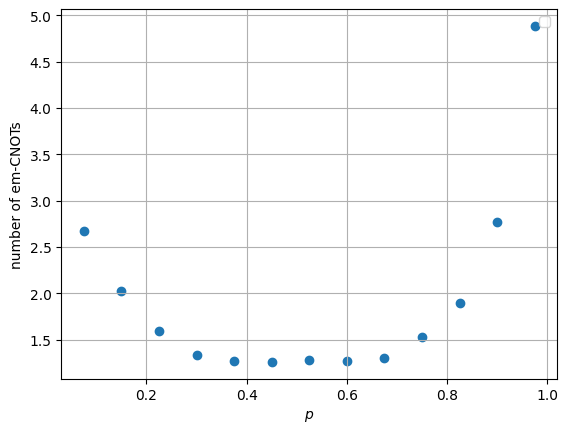

In [17]:
fig, ax = plt.subplots()
ax.grid(visible=True,which='both',axis='both')
#ax.set_xscale('log')
#ax.set_yscale('log')
# ax.yaxis.set_major_formatter(ScalarFormatter())
#ax.plot(n_p_tests,n_p_tests)
#ax.plot(tests,tests**2)
line_color = sns.color_palette("Set1")[0]
#sns.lineplot(x=n_p_tests, y=(np.ceil(n_p_tests/3)), label=r'random ordering', marker='o',color=line_color)
#ax.errorbar(n_p_tests, np.ceil(n_p_tests/3), yerr=1, fmt='o', capsize=5,color=line_color)
#sns.lineplot(x=p_tests*24, y=mean_em[:][0], label=r'random ordering', marker='o',color=line_color)
#ax.errorbar(p_tests, mean_em[:][0], yerr=mean_em[:][1], fmt='o', capsize=5,color=line_color,label='random ordering')
#ax.errorbar(p_tests,mean_cnot[:][0],yerr=mean_cnot[:][1], fmt='o', capsize=5,label=r'w/o optimization')
line_color = sns.color_palette("Set1")[1]
#sns.lineplot(x=p_tests*24, y=opt_mean_em[:][0], label=r'minLA', marker='o',color = line_color)
#ax.errorbar(p_tests, opt_mean_em[:][0], yerr=opt_mean_em[:][1], fmt='o', capsize=5,color = line_color,label='LC + minLA')
#ax.errorbar(p_tests[:5],opt_mean_cnot[:][0],yerr=opt_mean_cnot[:][1], fmt='o', capsize=5,label=r'optimized CNOT-gate count')
#ax.errorbar(p_tests,double_opt_mean_cnot[:][0],yerr=double_opt_mean_cnot[:][1], fmt='o', capsize=5,label=r'LC + minLA + CNOT')
ax.scatter(p_tests,mean_cnot[:][0]/double_opt_mean_cnot[:][0])
#plt.xlabel('average node degree')
plt.xlabel(r'$p$')
plt.ylabel(r'number of em-CNOTs')
plt.legend()
#plt.savefig('optimization_erdosrenyi_nodedegree20_cnot.pdf')
plt.show()

In [9]:
n_p_tests = [10]#[16,20,24,28,32,40,48,56,64]
#p_tests = np.arange(0.05,1,0.05)
p = 0.95
mean_em = []
mean_cnot = []
opt_mean_em = []
opt_mean_cnot = []
double_opt_mean_cnot = []

for n_p in n_p_tests:
    #n_e_results,num_cnots = sample_random_graphs(n_p,p,num_shots=100,create_circiut=True)
    #mean_em.append([mean(n_e_results),std(n_e_results)])
    #mean_cnot.append([mean(num_cnots),std(num_cnots)])

    n_e_results,num_cnots = optimized_sample_random_graphs(n_p,p,num_shots=100,create_circuit=True)
    opt_mean_em.append([mean(n_e_results),std(n_e_results)])
    double_opt_mean_cnot.append([mean(num_cnots),std(num_cnots)]) 

  0%|          | 0/100 [00:00<?, ?it/s]

Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit generates correct graph
Circuit 

In [12]:
mean_em = np.array(mean_em).T
mean_cnot = np.array(mean_cnot).T
print(mean_em)
print(mean_cnot)
opt_mean_em = np.array(opt_mean_em).T
opt_mean_cnot = np.array(opt_mean_cnot).T
double_opt_mean_cnot = np.array(double_opt_mean_cnot).T
print(opt_mean_em)
print(opt_mean_cnot)
print(double_opt_mean_cnot)

[]
[]
[[1.34      ]
 [0.49436828]]
[]
[[0.68      ]
 [1.26396202]]


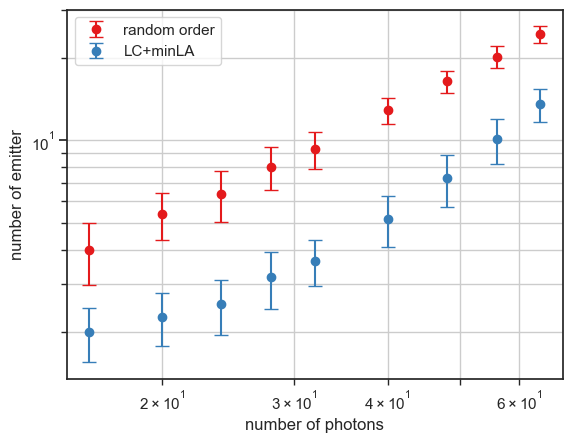

In [66]:
fig, ax = plt.subplots()
#sns.set_style(style="ticks")
ax.grid(visible=True,which='both',axis='both')
ax.set_xscale('log')
ax.set_yscale('log')
#ax.yaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_major_formatter(ScalarFormatter())
#ax.plot(n_p_tests,n_p_tests)
#ax.plot(tests,tests**2)
line_color = sns.color_palette("Set1")[0]
ax.errorbar(n_p_tests, mean_em[:][0], yerr=mean_em[:][1], fmt='o', capsize=5,color=line_color,label=r'random order')
#ax.errorbar(n_p_tests,mean_cnot[:][0],yerr=mean_cnot[:][1], fmt='o', capsize=5,label=r'CNOT-gate count', color='blue')
line_color = sns.color_palette("Set1")[1]
ax.errorbar(n_p_tests, opt_mean_em[:][0], yerr=opt_mean_em[:][1], fmt='o', capsize=5,color = line_color,label=r'LC+minLA')
#ax.errorbar(n_p_tests,double_opt_mean_cnot[:][0],yerr=double_opt_mean_cnot[:][1], fmt='o', capsize=5,label=r'LC + minLA + CNOT', color='black')
plt.xlabel('number of photons')
plt.ylabel(r'number of emitter')
plt.legend()
plt.savefig('erdoes_renyi_opt_p095_num_em.pdf')
plt.show()